<a href="https://colab.research.google.com/github/lyesbouchoucha/Resolution-Numerique-EDO-EDS/blob/main/Bouchoucha_Lyes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**TP noté - Méthodes numériques**

---



**Exercice 1** - Modèle de Lotka-Volterra

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
alpha=2/3
beta=4/3
gamma=1
delta=1
x0=1.5
y0=1.0
T=20
N=2000
h=T/N

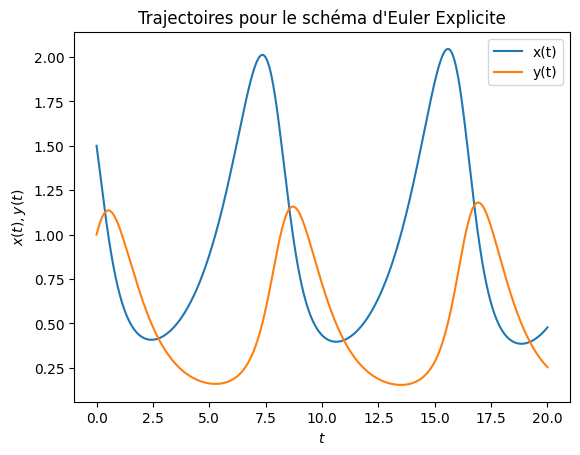

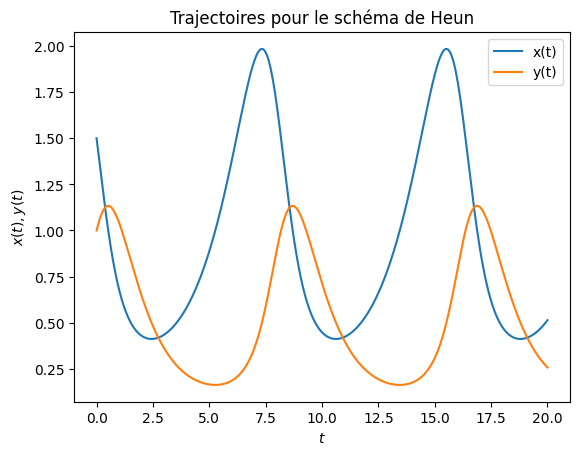

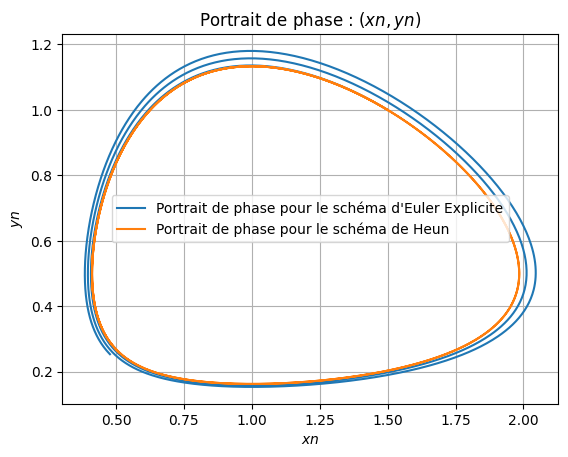

In [ ]:

def Lotka_Volterra(X,t,alpha,beta):
  x,y=X
  dxdt=alpha*x-beta*x*y
  dydt=-gamma*y+delta*x*y
  return [dxdt,dydt]

def euler_explicite(y,t,h):
  n=len(t)
  d=len(y)
  X=np.zeros((n,d))
  X[0]=y
  for i in range(1,n):
    X[i]=X[i-1]+h*np.array(Lotka_Volterra(X[i-1],t[i-1],alpha,beta))
  return X

def heun(y,t,h):
  n=len(t)
  d=len(y)
  X=np.zeros((n,d))
  X[0]=y
  for i in range(1,n):
    k1=np.array(Lotka_Volterra(X[i-1],t[i-1],alpha,beta))
    k2=np.array(Lotka_Volterra(X[i-1]+h*k1,t[i],alpha,beta))
    X[i]=X[i-1]+0.5*h*(k1+k2)
  return X


y=np.array([x0,y0])
t=np.linspace(0,T,N+1)
sol_euler=euler_explicite(y,t,h)
sol_heun=heun(y,t,h)
x_euler=sol_euler[:,0]
y_euler=sol_euler[:,1]
x_heun=sol_heun[:,0]
y_heun=sol_heun[:,1]

plt.figure()
plt.plot(t,x_euler, label="x(t)")
plt.plot(t,y_euler, label="y(t)")
plt.legend()
plt.xlabel(r'$t$')
plt.ylabel(r'$x(t),y(t)$')
plt.title("Trajectoires pour le schéma d'Euler Explicite")
plt.show()

plt.figure()
plt.plot(t,x_heun, label="x(t)")
plt.plot(t,y_heun, label="y(t)")
plt.legend()
plt.xlabel(r'$t$')
plt.ylabel(r'$x(t),y(t)$')
plt.title("Trajectoires pour le schéma de Heun")
plt.show()



plt.figure()

plt.plot(x_euler, y_euler,label="Portrait de phase pour le schéma d'Euler Explicite")


plt.plot(x_heun,y_heun,label="Portrait de phase pour le schéma de Heun")


plt.xlabel(r'$xn$')
plt.ylabel(r'$yn$')
plt.title("Portrait de phase : $(xn,yn)$")
plt.legend()
plt.grid(True)
plt.show()

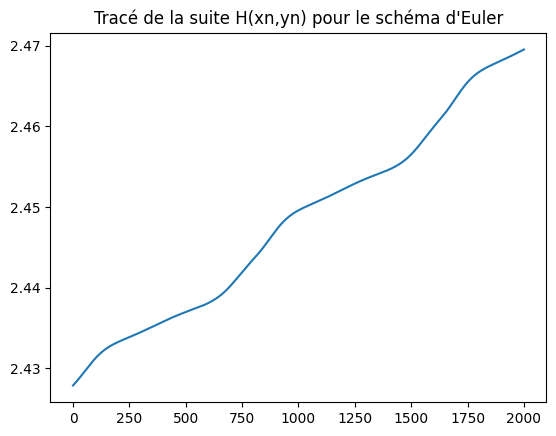

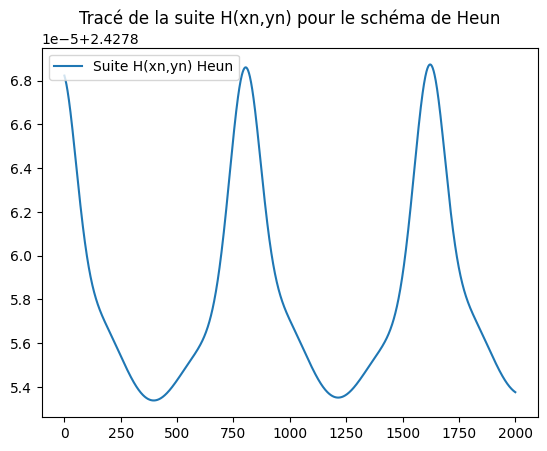

In [ ]:

def H(x,y):
  return(delta*x-gamma*np.log(x)+beta*y-alpha*np.log(y))

H_euler=H(x_euler,y_euler)
H_heun=H(x_heun,y_heun)
y=np.array([x0,y0])

plt.figure()
n=[tn/h for tn in t]
plt.plot(n, H_euler, label='Suite H(xn,yn) Euler')
plt.title("Tracé de la suite H(xn,yn) pour le schéma d'Euler")
plt.show()

plt.figure()
plt.plot(n,H_heun, label='Suite H(xn,yn) Heun')
plt.title("Tracé de la suite H(xn,yn) pour le schéma de Heun")
plt.legend()
plt.show()

Pour Euler Explicite, l'écart est croissant non borné.
Pour Heun, l'écart est borné. La fonction H est une quantité conservée par la solution exacte par hypothèse or pour heun on voit que l'erreur est borné donc H(x,y) sera proche de H(x0,y0)

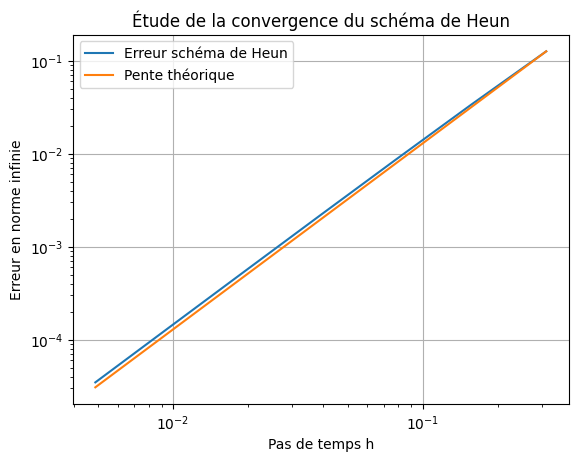

L'ordre de convergence estimé est : 1.974002767775664


In [ ]:
from scipy.integrate import solve_ivp

def f(t,u):
  x,y=u
  return [alpha*x-beta*x*y,-gamma*y+delta*x*y]
y=np.array([x0,y0])
sol_ref=solve_ivp(f,[0,T],y,method='RK45',rtol=1e-12,atol=1e-12,dense_output=True)



N_list=[2**k for k in range(6,13)]
errors=[]
h_list=[]
for N in N_list:
  h=T/N
  t=np.linspace(0,T,N+1)
  sol_heun=heun(y,t,h)
  x_heun=sol_heun[:,0]
  x_ref=sol_ref.sol(t)[0]
  erreur=np.max(np.abs(x_heun-x_ref))
  errors.append(erreur)
  h_list.append(h)

plt.figure()
plt.loglog(h_list,errors,label="Erreur schéma de Heun")

plt.loglog(h_list,[h**2*errors[0]/h_list[0]**2 for h in h_list], label="Pente théorique")

plt.xlabel("Pas de temps h")
plt.ylabel("Erreur en norme infinie")
plt.title("Étude de la convergence du schéma de Heun")
plt.legend()
plt.grid(True)
plt.show()
pente = np.polyfit(np.log(h_list), np.log(errors),1)[0]
print("L'ordre de convergence estimé est :", pente)

Le graphique confirme que Heun est d'ordre 2

**Exercice 2** - Modèle de Black-Sholes : Pricing par Monte Carlo

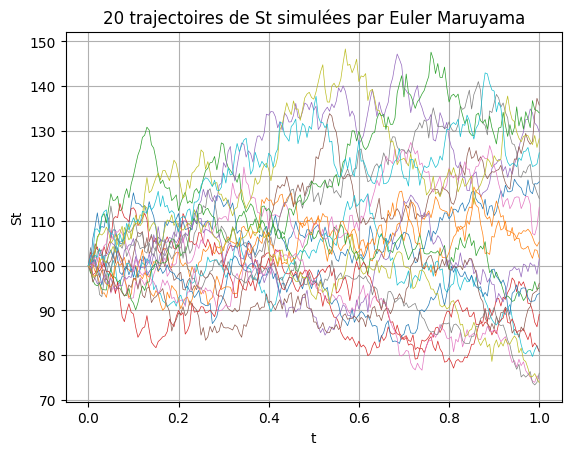

In [ ]:
S0=100
mu=0.08
sigma=0.25
r=0.04
T=1
K=105
N=200
M=10000

mu1=2*mu+sigma**2
sigma1=2*sigma
h = T/N

increments=np.random.normal(0,1,(M,N))
S_EM=np.zeros((M,N+1))
S_EM[:,0]=S0
for i in range(1,N+1):
  S_EM[:,i]=S_EM[:,i-1]+r*S_EM[:,i-1]*h+sigma*S_EM[:,i-1]*increments[:,i-1]*np.sqrt(h)


t=np.linspace(0,T,N+1)
plt.figure()
for i in range(20):
  plt.plot(t,S_EM[i,:], linewidth=0.5)

plt.grid(True)
plt.xlabel("t")
plt.ylabel("St")
plt.title("20 trajectoires de St simulées par Euler Maruyama")
plt.show()

On utilise r pour le pricing d'option car si on utilise mu on peut répliquer les gains de l'option en empruntant à la banque au taux r et ça couterait moins cher que le prix de l'option

In [ ]:
from scipy.stats import norm

d1=(np.log(S0/K)+(r+0.5*sigma**2)*T)/(sigma*np.sqrt(T))
d2=d1-sigma*np.sqrt(T)
BS_price=S0*norm.cdf(d1)-K*np.exp(-r*T)*norm.cdf(d2)


payoff_call=np.maximum(S_EM[:,N]-K,0)
prix_mc=np.exp(-r*T)*payoff_call

def intervalle_conf(data, num_iterations=10000, alpha=0.05):
    n = len(data)
    means = np.zeros(num_iterations)
    for i in range(num_iterations):
        means[i] = np.mean(np.random.choice(data, size=n, replace=True))
    means.sort()
    lower_bound = means[int(num_iterations * (alpha / 2))]
    upper_bound = means[int(num_iterations * (1 - alpha / 2))]
    mean_estimate = np.mean(means)
    return mean_estimate, (lower_bound, upper_bound)


C0,(lb, ub)=intervalle_conf(prix_mc)


print("Le prix théorique de Black Scholes est :", BS_price)
print("Le prix estimé par Monte Carlo est :", C0)
print("L'intervalle de confiance est :", lb, ub)

Le prix théorique de Black Scholes est : 9.55625620516362
Le prix estimé par Monte Carlo est : 9.631396859570556
L'intervalle de confiance est : 9.314130992490007 9.959977466808004


La valeur exacte tombe bien dans l'intervalle de confiance donc notre estimateur monte carlo est bon

Valeur analytique : 12491.95819650653
Estimation Monte Carlo : 12581.85644400479
Intervalle de confiance : 12446.175951378047 12715.618550808773


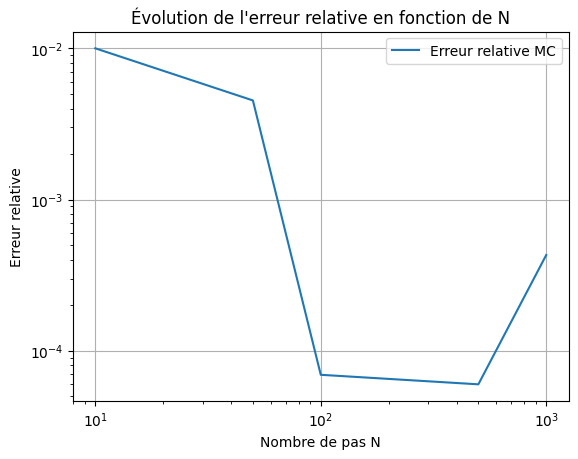

In [ ]:
E_S2=(S0**2)*np.exp(mu1*T)
S_em_N=np.zeros(M)
S_em_N=S0
for i in range(N):
    increments=np.random.normal(0,1,M)
    S_em_N=S_em_N+mu*S_em_N*h+sigma*S_em_N*increments*np.sqrt(h)


esperance_S2,(lb,ub)=intervalle_conf(S_em_N**2)

print("Valeur analytique :", E_S2)
print("Estimation Monte Carlo :", esperance_S2)
print("Intervalle de confiance :",lb,ub)


N_list=[10, 50, 100, 500, 1000]
errors=[]
for Ns in N_list:
  h=T/Ns
  S_em=np.zeros(M)
  S_em=S0
  for i in range(Ns):
    Z=np.random.normal(0, 1, M)
    S_em=S_em+mu*S_em*h+sigma*S_em*Z*np.sqrt(h)
  S2_m=np.mean(S_em**2)
  errors.append(np.abs(S2_m-E_S2)/E_S2)

plt.figure()
plt.loglog(N_list,errors, label="Erreur relative MC")
plt.xlabel("Nombre de pas N")
plt.ylabel("Erreur relative")
plt.title("Évolution de l'erreur relative en fonction de N")
plt.grid(True)
plt.legend()
plt.show()